<a href="https://colab.research.google.com/github/fzunigaGH/Proyectos/blob/main/Detecci%C3%B3n_temprana_de_Churn_utilizando_bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Detección temprana de Churn

##El Problema

La oferta de servicios de telefonía ha ido en aumento en los últimos años, provocando una alta competencia que se traduce en menores precios y mejores prestaciones. Sin embargo, los operadores de servicios de telecomunicaciones luchan día a día por retener a sus clientes, ya que el costo de un nuevo cliente es mayor comparado con el costo de retener uno antiguo.

##Objetivo

Entrenar un modelo de ensamble que permita predecir
tempranamente si un cliente renunciará a la compañía de Telecomunicaciones mandante, además de poder explicar cuál o cuáles son las características que más incidencia tienen en la separación de clientes con y sin renuncia.

##Diccionario de Datos

1. **Churn (Variable objetivo):** valor 1 si el cliente canceló el servicio, 0 si no
2. **AccountWeeks:** número de semanas que el cliente ha tenido activa la cuenta
3. **ContractRenewal:** toma el valor 1 si el cliente ha renovado recientemente el contrato,
0 en caso contrario
4. **DataPlan:** valor 1 si el cliente tiene plan de datos, 0 en caso contrario
5. **DataUsage:** Gigabytes de uso mensual de datos
6. **CustServCalls:** número de llamadas al servicio de atención al cliente
7. **DayMins:** promedio de minutos diurnos al mes
8. **DayCalls:** número medio de llamadas diurnas
9. **MonthlyCharge:** factura mensual media
10. **OverageFee:** mayor cuota de exceso en los últimos 12 meses
11. **RoamMin:** minutos de Roaming

##Metodología

1. En primera instancia se procederá a importar la base de datos provista por el cliente, con la información detallada en el diccionario de datos. Junto con las librerías necesarias para el desarrollo del proyecto.

2. Posteriormente se procederá a realizar un análisis exploratorio de los datos disponibles (EDA), con la finalidad de identificar datos faltantes y/o duplicados, presencia de valores atípicos, relaciones entre variables y otros análisis previos al desarrollo de los modelos según sea necesario.

3. A continuación se realizará un feature engineering para escalar y codificar los atributos antes de generar los modelos de machine learning.

4. Posteriormente se evaluarán los siguientes modelos de ML:

  4.1. Modelo de árbol de decisión sin modificar parámetros por defecto

  4.2. Se modificarán los parámetros del modelo anterior en función de la siguiente grilla:


*   **max_depth:** [5, 10, 15, 20. 25]
*   **min_sample_split:** [0.01, 0.02, 0.03, 0.04]

5. Con el modelo optimizado resultante del punto 4.2 se realizará balanceo de clases usando SMOTE para el conjunto de entrenamiento y se aplicará un modelo de bagging con 200 estimadores.

6. Luego se procederá a implementar un modelo de Bagging utilizando modelos heterogéneos con los siguiente estimadores:
* Regresión logística
* Árbol de Decisión
* Support Vector Machine classifier (SVMC) con kernel **rbf**
* Support Vector Machine classifier (SVMC) con kernel **sigmoid**

Lo anteior considerando 200 muestras bootstrap (T).

7. Posteriormente se implementará un modelo de ensamble, Random Forest (usando como hiper parámetro
n_estimators = 45). El modelo usará muestra OOB para estimar su ajuste (ACCURACY). Junto con lo anterior se identificarán las cuatro características más importantes junto con las
métricas de desempeño en el conjunto de test.

8. En penúltima instancia se realizará una búsqueda de grilla para un modelo Random Forest con los siguientes rangos de valores para sus hiper parámetros:
- **n_estimators:** 50 - 200 con paso de 10 completando 15 valores
- **max_features:** [‘sqrt’, ‘log2’, None]

8. Finalmente, usando el modelo Random Forest con sus hiper parámetros ajustados, se listarán los 15 clientes que presentan la mayor propensión a renunciar.











##1. Librerías, Base de Datos y definición de funciones

###1.1. Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mode
from scipy.stats import pearsonr, chi2_contingency

#modelos requerido
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score, recall_score, confusion_matrix, precision_score
from sklearn.metrics import roc_curve, roc_auc_score


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###1.2. Carga de Base de Datos

In [ ]:
df_readed = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/01 - Modelos de ensamble (parte I)/Desafio 01 - modelos de ensamble (parte I)/telecom_churn.csv')

In [ ]:
df = df_readed

###1.3. Funciones

In [ ]:
def remove_outliers(df, column):# función remove_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return  df_desafio

def identifica_outliers(df, column):# función identifica_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    sns.boxplot(df[column])
    plt.show()
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_SO = df[(df[column]< lower_bound) | (df[column] > upper_bound)]
    #print(f"\n\nA continuación se presentan los registros outliers\n")
    #sns.histplot(df_SO[column], bins= 20
    return df_SO

def df_sin_outliers(df, column): # función que retorna un DataFrame sin elementos outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_desafio


In [ ]:
def correlacion(datos, target, dicotomic = False):
  numeric_features = datos.select_dtypes(include=[np.number]).columns.tolist()
  for feature in numeric_features:
    dfi = datos.loc[:, [feature, target]].dropna()
    corr, _ = pearsonr(dfi[feature], dfi[target])
    if isinstance(corr, np.ndarray):
      print(f"Correlación de Pearson entre {feature} y {target}: {corr[0]:.2f}")
    else:
      print(f"Correlación de Pearson entre {feature} y {target}: {corr:.2f}")

  correlation_matrix_numeric = datos[numeric_features].corr()

  plt.rcParams.update({'font.size': 12})
  plt.figure(figsize = (4,8))
  sns.heatmap(correlation_matrix_numeric.loc[:, [target]].sort_values(target, ascending = False).iloc[1:], cmap = 'Reds', annot = True)

  categorical_features = datos.select_dtypes(include=[object]).columns.tolist()
  if dicotomic == True:
    for feature in categorical_features:
      target_modificado = datos[target].replace({1: 'Positiva', 0: 'Negativa'})
      chi2, p, _, _ = chi2_contingency(pd.crosstab(datos[feature], target_modificado))
      if p < 0.05:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Hay relación entre las variables.")
      else:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Las variables son independientes.")
  return numeric_features, categorical_features


In [ ]:

def bagging_het(X_train, y_train, T, estimators, X_test):
    """
    Crea un modelo Bagging usando estimadores heterogéneos.
    En que genera una cantidad T de muestras bootstrap y
    para cada una de ellas se entrena un estimador escogido
    en forma aleatoria desde la bolsa disponible.
    La estimación final usando los modelos entrenados se
    realiza por mayoría de votos.

    Basado en

    Parámetros:
    -----------
    X_train : DataFrame
        Conjunto de entrenamiento sin columna target.
    y_train : Series
        Datos con las clases asociadas a cada obs. de X_train
    T : int
        Representa la cantidad de muestras bootstrap a generar,
        equivalente a la cantidad de estimadores a entrenar.
    X_test : DataFrame
        Conjunto de test sobre el cual se somete el ensamble

    Retorna:
    --------
    list
        Lista con los estimadores entrenados

    np.array
        Array con cantidad de filas igual a la cantidad de
        observaciones de X_test y T columnas cada una con
        la clasificación predicha por el estimador asignado

    Series
        resultado por mayoría de votos para el conjunto de test

    list
        Lista con los índices no repetidos de las observaciones
        excluidad en cada muestra bootstrap
    """

    trained_model = []
    yhat_test = np.zeros((X_test.shape[0], T))
    idx_oob = []
    for t in np.arange(0, T):
        sa1 = X_train.sample(n=X_train.shape[0], replace=True)

        idx_oob = list(set(idx_oob + list(set(X_train.index)-set(sa1.index))))

        idx_estimator = np.random.randint(0, len(estimators))
        estimator = estimators[idx_estimator]
        #print(idx_estimator, end='; ')

        estimator.fit(sa1, y_train[sa1.index])
        trained_model.append(estimator)

        yhat_test[:,t] = estimator.predict(X_test)

    yhat_out = pd.Series(data=mode(yhat_test, axis=1)[0], name='yhat')

    return trained_model, yhat_test, yhat_out, idx_oob


def bagging_het_predict(X, estimators):
    yhat = np.zeros((X.shape[0], len(estimators)))

    for i, est in enumerate(estimators):
        yhat[:,i] = est.predict(X)

    return pd.Series(data=mode(yhat, axis=1)[0], name='yhat')




##2. Análisis Exploratorio de Datos (EDA)

In [ ]:
df.head(2)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,3333.0,0.144914,0.352067,0.0,0.00,0.00,0.00,1.00
AccountWeeks,3333.0,101.064806,39.822106,1.0,74.00,101.00,127.00,243.00
ContractRenewal,3333.0,0.903090,0.295879,0.0,1.00,1.00,1.00,1.00
DataPlan,3333.0,0.276628,0.447398,0.0,0.00,0.00,1.00,1.00
DataUsage,3333.0,0.816475,1.272668,0.0,0.00,0.00,1.78,5.40
CustServCalls,3333.0,1.562856,1.315491,0.0,1.00,1.00,2.00,9.00
DayMins,3333.0,179.775098,54.467389,0.0,143.70,179.40,216.40,350.80
DayCalls,3333.0,100.435644,20.069084,0.0,87.00,101.00,114.00,165.00
MonthlyCharge,3333.0,56.305161,16.426032,14.0,45.00,53.50,66.20,111.30
OverageFee,3333.0,10.051488,2.535712,0.0,8.33,10.07,11.77,18.19


In [ ]:
qty_inicial_registros = df.shape[0]
print(f'Cantidad inicial de registros: {qty_inicial_registros}')

Cantidad inicial de registros: 3333


/tmp/ipykernel_4296/2192851579.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_name, data=df, ax=ax, palette='viridis')
/tmp/ipykernel_4296/2192851579.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_name, data=df, ax=ax, palette='viridis')
/tmp/ipykernel_4296/2192851579.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_name, data=df, ax=ax, palette='viridis')


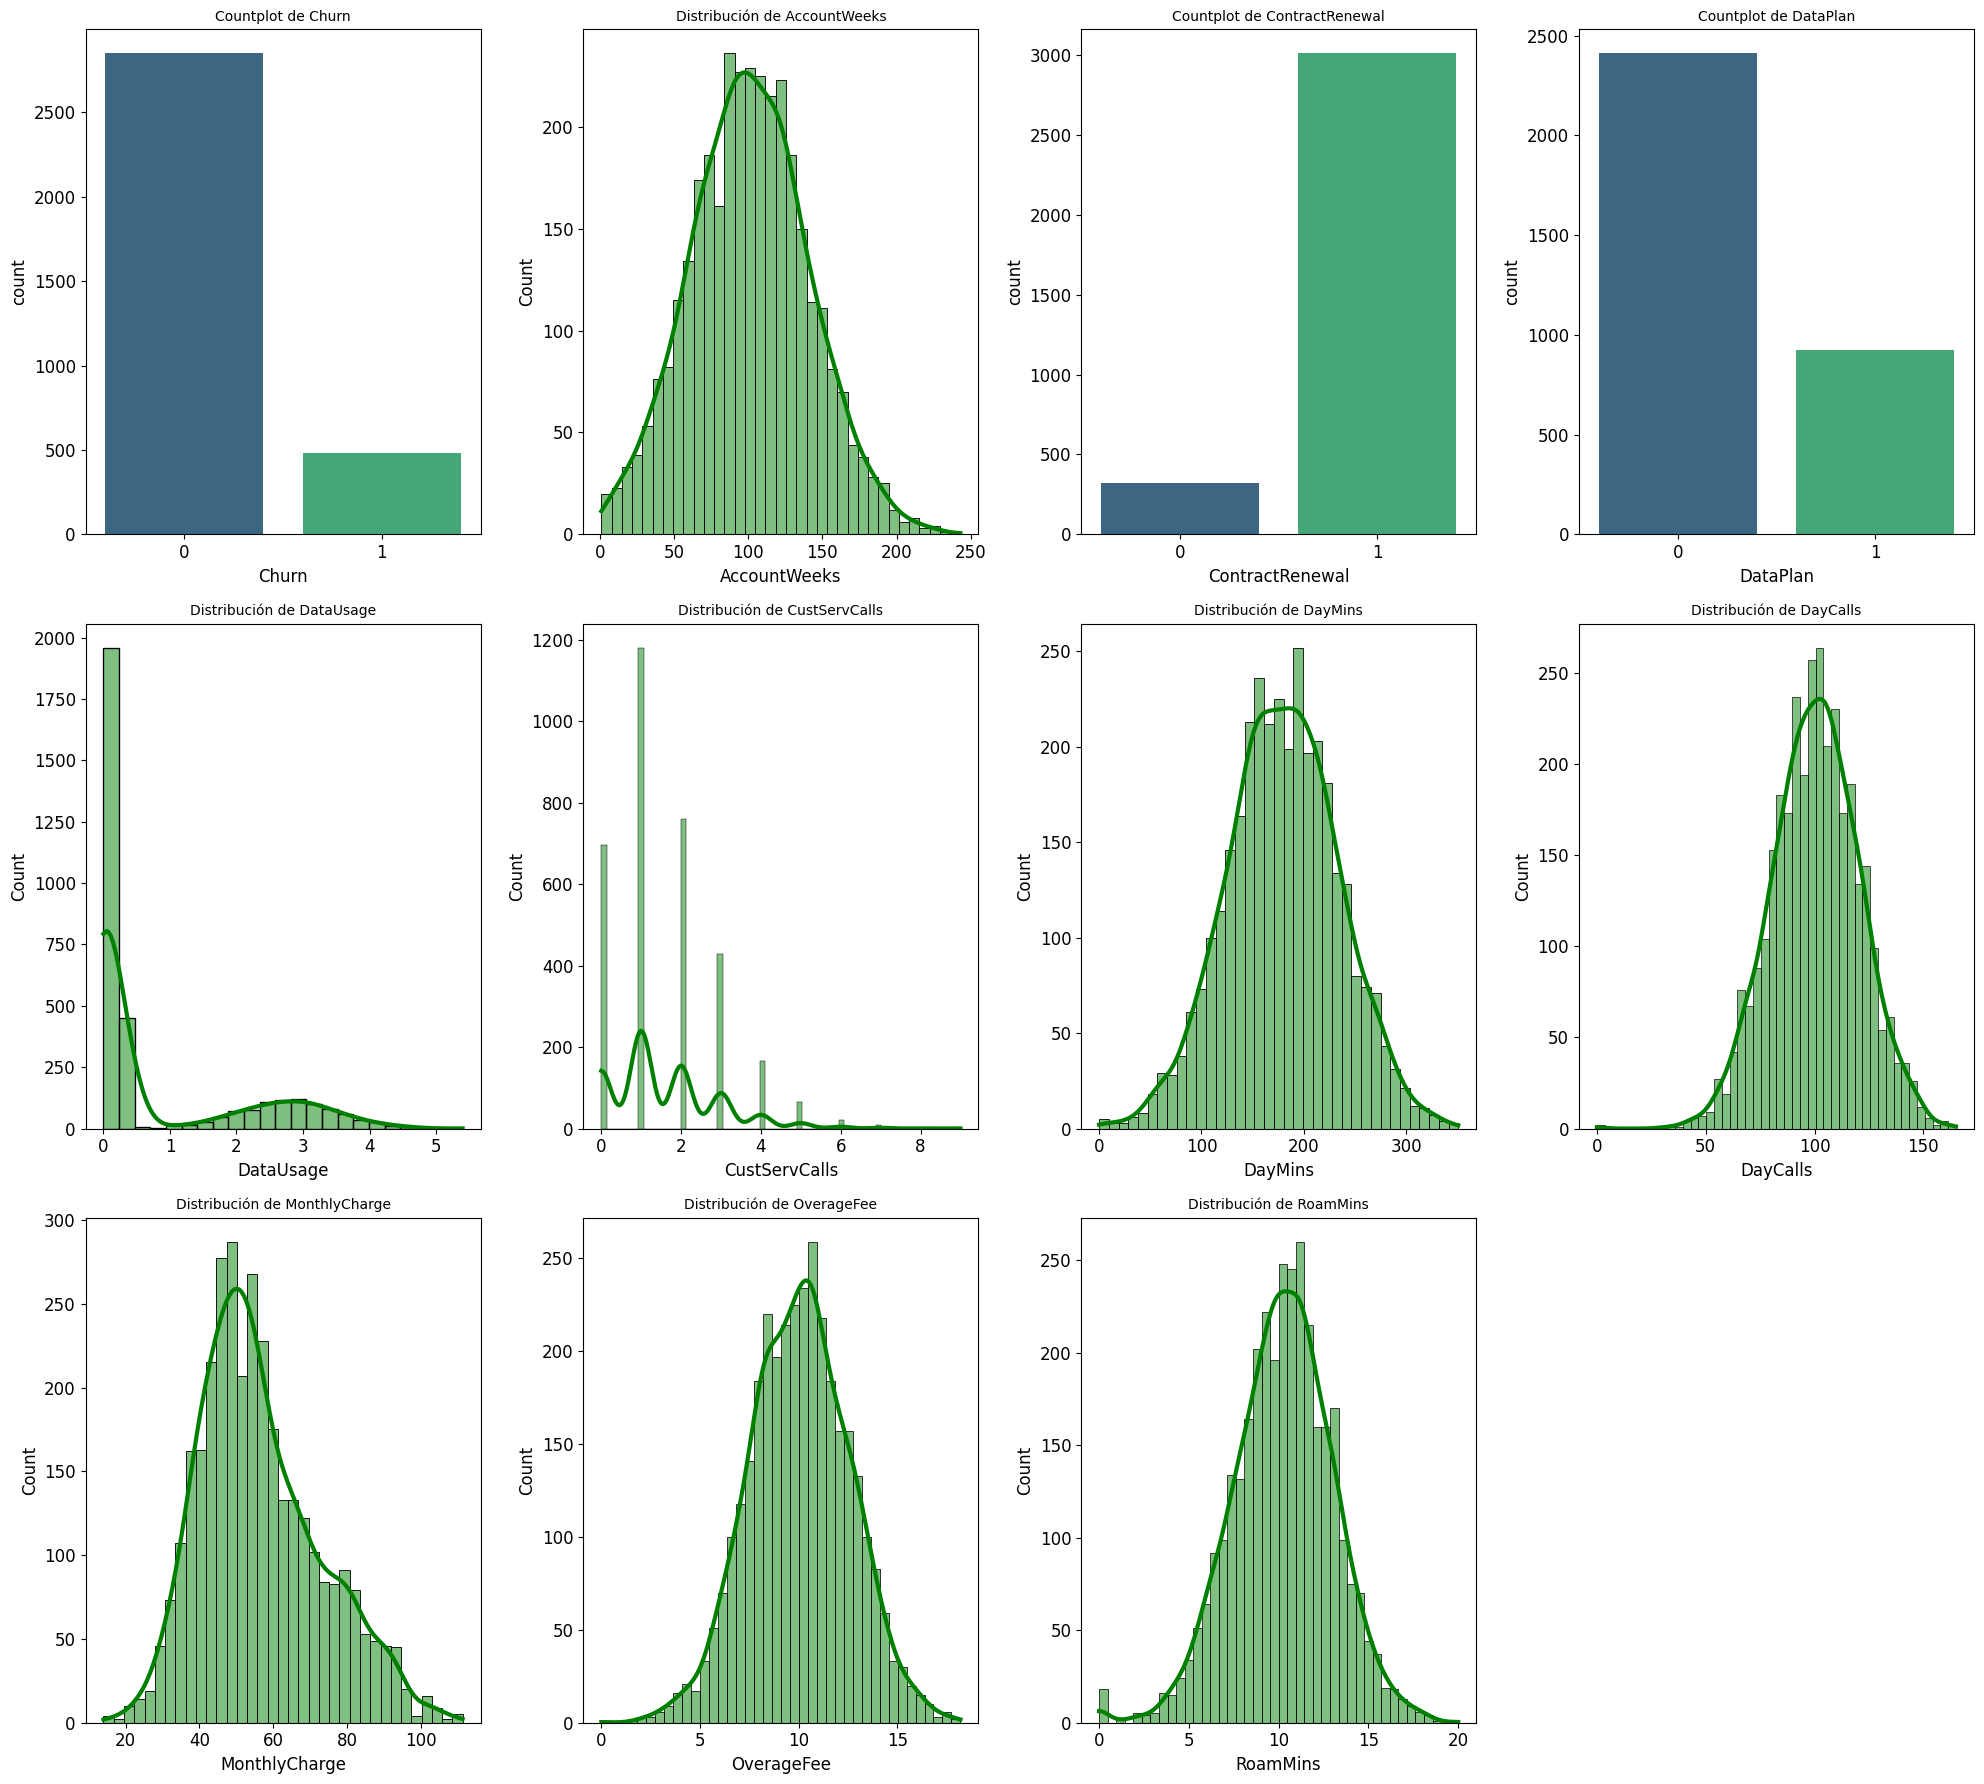

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 18))
axes_flat = axes.flatten()

# 3. Iteramos usando un solo contador para los ejes, ahora sobre todas las columnas de df
for i, col_name in enumerate(df.columns):
    if i >= len(axes_flat): # Asegurarse de no exceder el número de subplots disponibles
        break

    ax = axes_flat[i]

    # Verificar si la columna es categórica (objeto o binaria 0/1)
    if pd.api.types.is_object_dtype(df[col_name]) or (df[col_name].nunique() == 2 and df[col_name].isin([0, 1]).all()):
        sns.countplot(x=col_name, data=df, ax=ax, palette='viridis')
        ax.set_title(f"Countplot de {col_name}", fontsize=10)
    else: # Si es numérico
        sns.histplot(
            data=df,
            x=col_name,
            kde=True,
            ax=ax,
            color='green',           # Color de las barras (suave para resaltar la línea)
            line_kws={'color': 'red', 'linewidth': 3} # Forzar color y grosor de la línea
        )
        ax.set_title(f"Distribución de {col_name}", fontsize=10)

# Eliminar subplots no utilizados si hay menos columnas que slots de subplots
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

### Revisión presencia de elementos duplicados

In [ ]:
df.drop_duplicates()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0


### Análisis presencia de elementos Outliers por atributos

###Análisis atributo **AccontWeeks**:

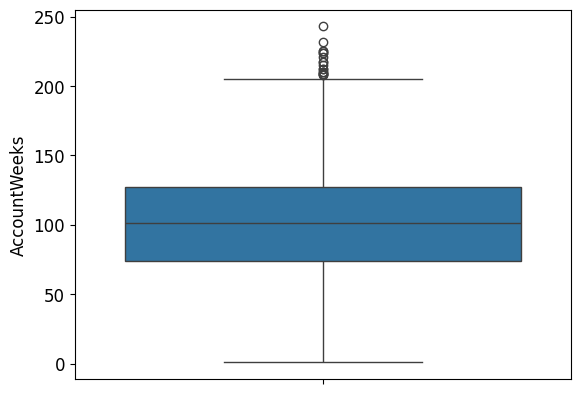

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
197,1,208,1,0,0.33,2,326.5,67,74.3,8.82,10.7
238,0,215,1,0,0.31,0,83.6,148,28.1,6.05,10.7
309,0,209,1,0,0.00,3,227.2,128,61.0,12.92,8.9
416,1,224,0,0,0.26,1,171.5,99,45.6,8.00,5.0
817,0,243,1,0,0.00,2,95.5,92,31.0,8.19,6.6
1045,0,217,1,0,0.00,4,176.4,115,44.0,7.94,9.3
1093,0,210,1,0,0.28,2,104.6,121,33.8,7.48,6.5
1387,0,212,1,0,0.00,1,126.0,96,34.0,7.22,7.6
1408,0,232,1,0,0.14,1,165.6,104,46.4,9.80,11.8
1551,1,225,1,0,0.30,0,165.4,106,55.0,13.69,8.7


In [ ]:
identifica_outliers(df, 'AccountWeeks')

###Análisis atributo **ContractRenewal**:

In [ ]:
df['ContractRenewal'].value_counts()

,count
ContractRenewal,
1,3010
0,323


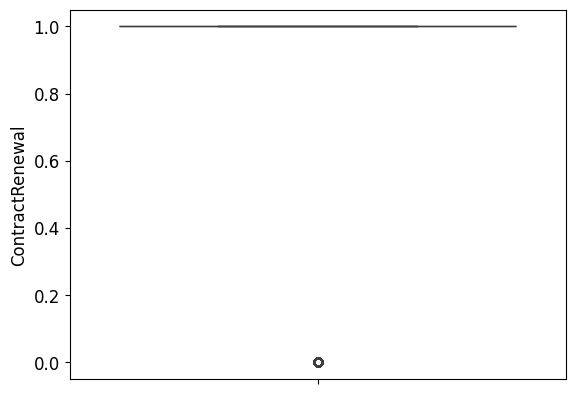

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
5,0,118,0,0,0.00,0,223.4,98,57.0,11.03,6.3
7,0,147,0,0,0.00,0,157.0,79,36.0,5.16,7.1
9,0,141,0,1,3.02,0,258.6,84,93.2,11.10,11.2
...,...,...,...,...,...,...,...,...,...,...,...
3304,1,71,0,0,0.00,4,186.1,114,49.0,9.93,13.8
3309,0,100,0,0,0.00,4,219.4,112,57.0,11.29,12.0
3317,0,163,0,0,0.00,1,197.2,90,50.0,9.43,7.8
3320,1,122,0,0,0.30,4,140.0,101,44.0,9.82,9.7


In [ ]:
identifica_outliers(df, 'ContractRenewal')

<Axes: xlabel='ContractRenewal', ylabel='Count'>

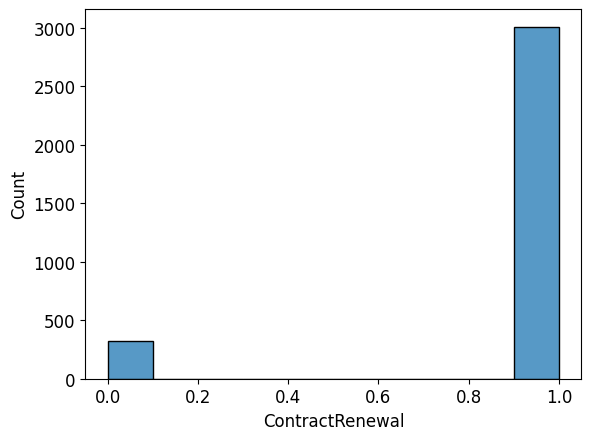

In [ ]:
sns.histplot(df['ContractRenewal'], bins= 10)

**Conclusión:**
* Se confirma que el atributo corresponde a un atributo binomial
* El Dataset utilizado, presenta un desbalance considerable en este atributo, lo cual puede incidir en el desempeño de los modelos que serán evaluados posteriormente.




###Análisis atributo **DataPlan**:

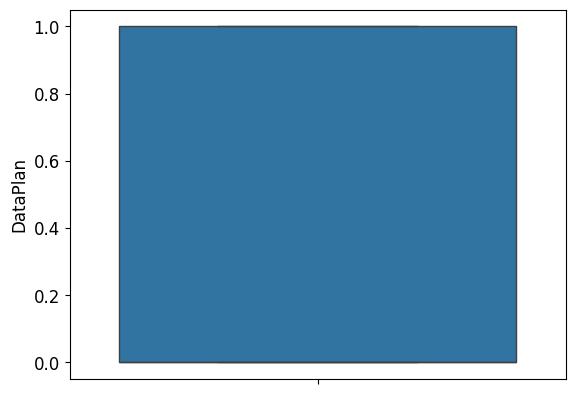

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins


In [ ]:
identifica_outliers(df, 'DataPlan')

In [ ]:
df['DataPlan'].value_counts()

,count
DataPlan,
0,2411
1,922


<Axes: xlabel='DataPlan', ylabel='Count'>

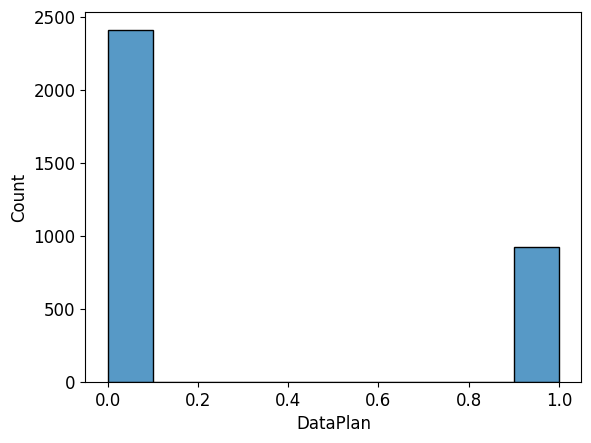

In [ ]:
sns.histplot(df['DataPlan'], bins= 10)

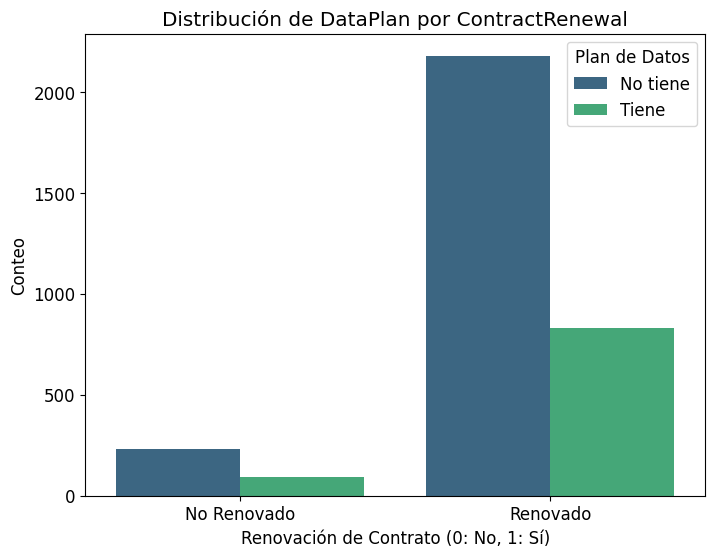

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='ContractRenewal', hue='DataPlan', data=df, palette='viridis')
plt.title('Distribución de DataPlan por ContractRenewal')
plt.xlabel('Renovación de Contrato (0: No, 1: Sí)')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1], labels=['No Renovado', 'Renovado'])
plt.legend(title='Plan de Datos', labels=['No tiene', 'Tiene'])
plt.show()

**Conclusión:**
* Este gráfico muestra cómo se distribuyen los clientes con y sin plan de datos en función de si han renovado su contrato o no. Puedes observar si hay alguna relación evidente entre tener un plan de datos y la renovación del contrato.

###Análisis atributo **DataUsage**:

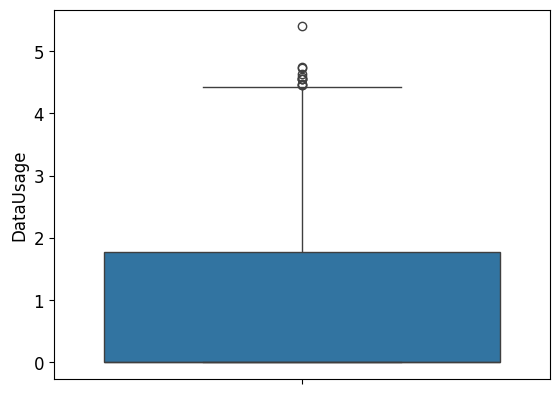

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
115,1,36,0,1,5.40,0,196.8,89,110.0,12.75,20.0
469,0,41,1,1,4.64,2,194.4,63,101.4,12.75,17.2
515,0,148,1,1,4.73,1,93.6,137,80.3,9.69,17.5
579,0,72,1,1,4.46,1,186.7,108,105.6,16.75,16.5
907,0,118,1,1,4.56,1,118.1,83,75.6,5.48,16.9
1127,0,159,1,1,4.56,0,184.1,78,93.6,9.73,16.9
1467,1,67,0,1,4.56,0,181.1,59,95.6,10.80,16.9
1579,0,148,1,1,4.46,2,209.2,110,90.6,5.83,16.5
2229,0,83,1,1,4.75,2,191.3,95,101.5,12.54,17.6
2687,1,125,0,1,4.59,1,260.8,81,104.9,8.19,17.0


In [ ]:
identifica_outliers(df, 'DataUsage')

In [ ]:
df = remove_outliers(df, 'DataUsage')

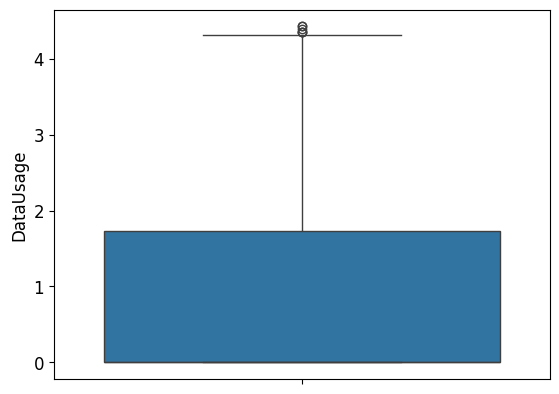

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
670,0,32,1,1,4.40,1,266.7,109,110.0,11.62,16.3
724,0,129,1,1,4.43,1,192.8,103,92.3,8.85,16.4
839,0,88,1,1,4.35,1,219.5,78,100.5,11.11,16.1
1041,0,161,1,1,4.35,0,240.4,112,102.5,10.09,16.1
2096,0,94,1,1,4.35,0,233.2,88,93.5,5.67,16.1
2122,0,69,1,1,4.43,0,268.8,78,111.3,12.33,16.4


In [ ]:
identifica_outliers(df, 'DataUsage')

**Conclusión**: Dado que los elementos outliers están prácticamente en el límite superior del intervalo y sólo son 3 elementos, estos se mantendrán en el dataset que se utilizará para entrenar el modelo.

###Análisis atributo **CustServCalls**:

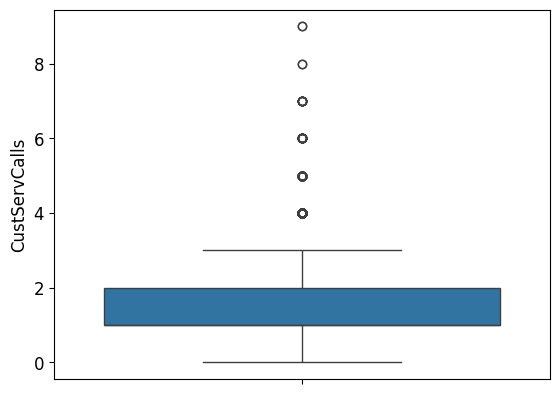

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
10,1,65,1,0,0.29,4,129.1,137,44.9,11.43,12.7
14,0,62,1,0,0.00,4,120.7,70,47.0,15.36,13.1
15,1,161,1,0,0.00,4,332.9,67,84.0,15.89,5.4
21,1,77,1,0,0.00,5,62.4,89,26.0,8.50,5.7
48,1,119,1,0,0.00,5,159.1,114,47.0,11.57,8.8
...,...,...,...,...,...,...,...,...,...,...,...
3307,0,172,1,0,0.00,4,203.9,109,55.0,11.70,17.8
3309,0,100,0,0,0.00,4,219.4,112,57.0,11.29,12.0
3320,1,122,0,0,0.30,4,140.0,101,44.0,9.82,9.7
3322,1,62,1,0,0.00,4,321.1,105,78.0,13.28,11.5


In [ ]:
identifica_outliers(df, 'CustServCalls')

In [ ]:
df = remove_outliers(df, 'CustServCalls')

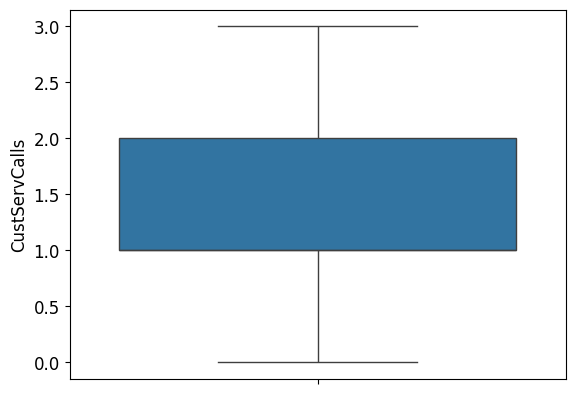

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins


In [ ]:
identifica_outliers(df, 'CustServCalls')

###Análisis atributo **DayMins**:

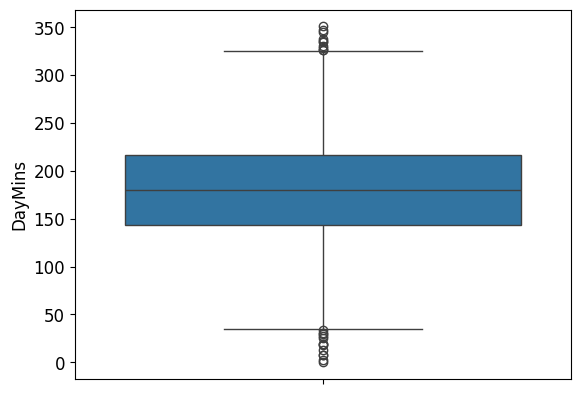

(23, 11)

In [ ]:
identifica_outliers(df, 'DayMins').shape

In [ ]:
df = remove_outliers(df, 'DayMins')

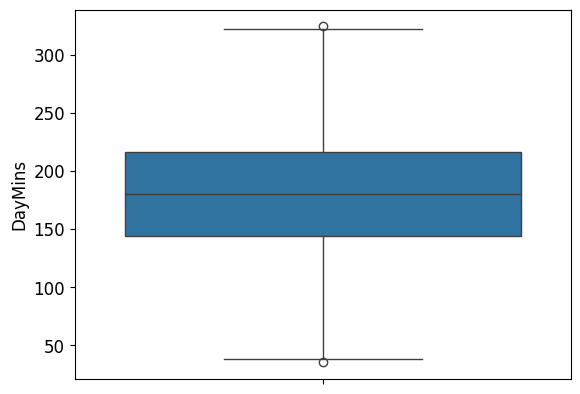

(2, 11)

In [ ]:
identifica_outliers(df, 'DayMins').shape

Conclusión: Dado que se aprecia sólo 1 elementos outliers y está prácticamente en el límite superior del intervalo, este se mantendrá en el dataset que se utilizará para entrenar el modelo.

###Análisis atributo **DayCalls**:

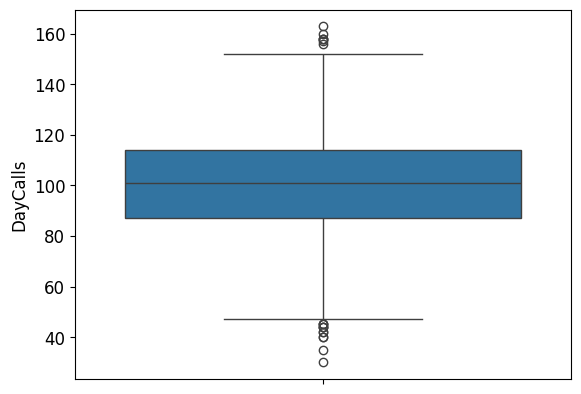

Se identifican 19 elementos outliers en el atributo DayCalls


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'DayCalls').shape[0]} elementos outliers en el atributo DayCalls')

In [ ]:
df = remove_outliers(df, 'DayCalls')

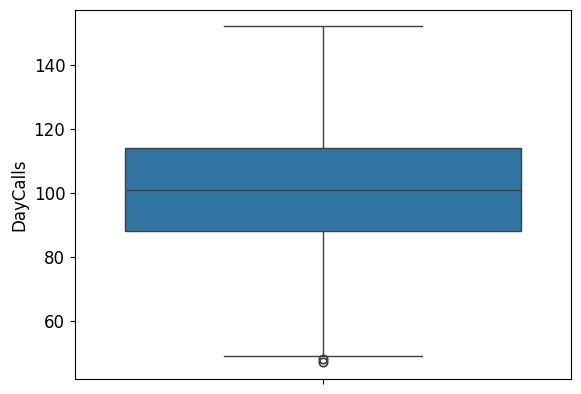

Se identifican 4 elementos outliers en el atributo DayCalls


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'DayCalls').shape[0]} elementos outliers en el atributo DayCalls')

Conclusión: Dado que los elementos outliers están prácticamente en el límite superior del intervalo y sólo son 4 elementos, estos se mantendrán en el dataset que se utilizará para entrenar el modelo.

###Análisis atributo **MonthlyCharge**:

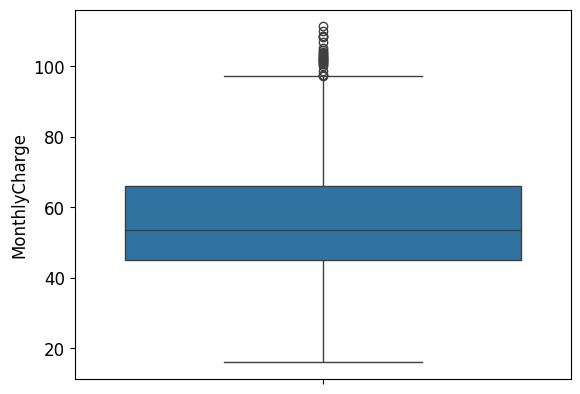

Se identifican 28 elementos outliers en el atributo DayCalls


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'MonthlyCharge').shape[0]} elementos outliers en el atributo DayCalls')

In [ ]:
df = remove_outliers(df, 'MonthlyCharge')


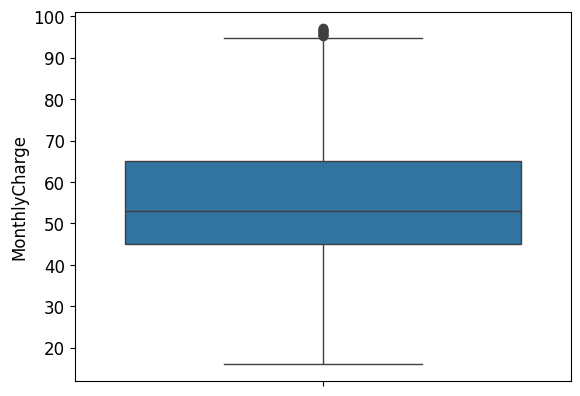

Se identifican 14 elementos outliers en el atributo DayCalls


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'MonthlyCharge').shape[0]} elementos outliers en el atributo DayCalls')

###Análisis atributo **OverageFee**:

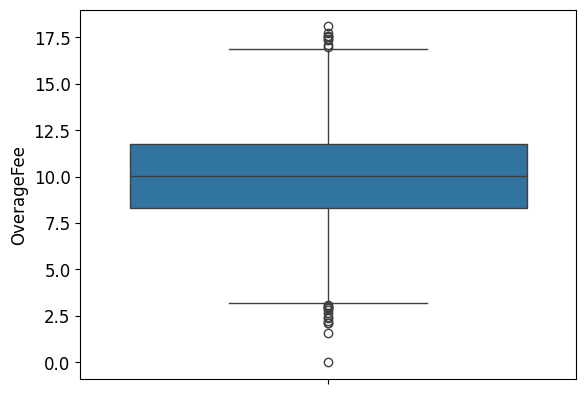

Se identifican 23 elementos outliers en el atributo DayCalls


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'OverageFee').shape[0]} elementos outliers en el atributo DayCalls')

In [ ]:
df = remove_outliers(df, 'OverageFee')

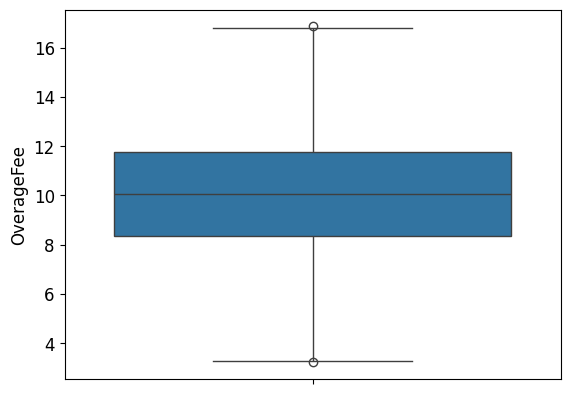

Se identifican 2 elementos outliers en el atributo DayCalls


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'OverageFee').shape[0]} elementos outliers en el atributo DayCalls')

###Análisis atributo **RoamMins**:

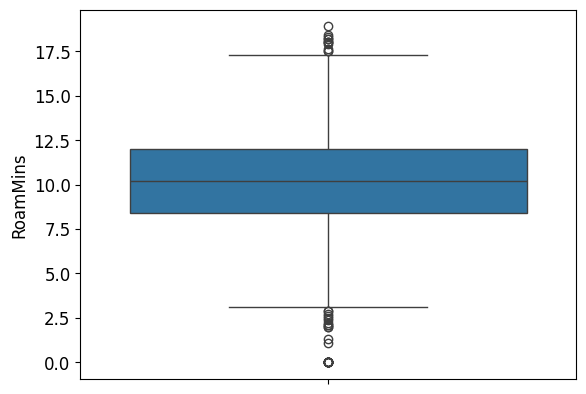

Se identifican 42 elementos outliers


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'RoamMins').shape[0]} elementos outliers')

In [ ]:
df = remove_outliers(df, 'RoamMins')

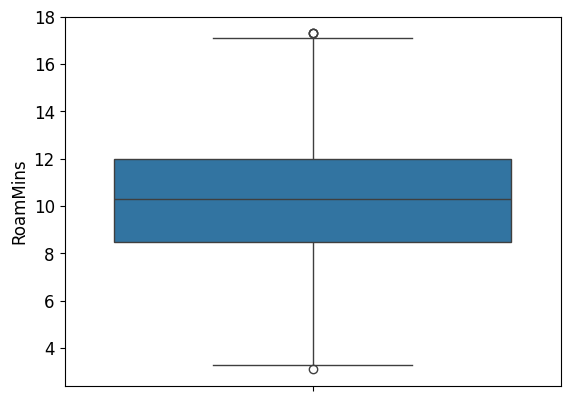

Se identifican 4 elementos outliers


In [ ]:
print(f'Se identifican {identifica_outliers(df, 'RoamMins').shape[0]} elementos outliers')

###2.1. Dataset sin elementos Outlier en sus atributos

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,2920.0,0.107877,0.310278,0.00,0.0000,0.00,0.00,1.00
AccountWeeks,2920.0,100.934932,40.173730,1.00,73.0000,100.00,128.00,243.00
ContractRenewal,2920.0,0.906507,0.291172,0.00,1.0000,1.00,1.00,1.00
DataPlan,2920.0,0.269863,0.443964,0.00,0.0000,0.00,1.00,1.00
DataUsage,2920.0,0.792075,1.239892,0.00,0.0000,0.00,1.73,4.43
CustServCalls,2920.0,1.307534,0.973762,0.00,1.0000,1.00,2.00,3.00
DayMins,2920.0,179.290479,52.210132,35.10,143.9750,179.30,215.50,324.70
DayCalls,2920.0,100.544178,19.321129,47.00,88.0000,101.00,114.00,152.00
MonthlyCharge,2920.0,55.966301,15.558050,16.00,45.0000,53.35,65.50,97.10
OverageFee,2920.0,10.044904,2.456862,3.22,8.3475,10.05,11.76,16.86


In [ ]:
qty_registros_after_EDA = df.shape[0]
print(f'Cantidad de registros after EDA: {qty_registros_after_EDA}, equivalentes al {qty_registros_after_EDA / qty_inicial_registros * 100 :0.1f} % de los {qty_inicial_registros} registros iniciales')

Cantidad de registros after EDA: 2920, equivalentes al 87.6 % de los 3333 registros iniciales


###2.2. Relaciones entre variables

A continuación se representan la relación existente entre la variable objetivo y las variables independientes

Correlación de Pearson entre Churn y Churn: 1.00
Correlación de Pearson entre AccountWeeks y Churn: 0.02
Correlación de Pearson entre ContractRenewal y Churn: -0.28
Correlación de Pearson entre DataPlan y Churn: -0.10
Correlación de Pearson entre DataUsage y Churn: -0.09
Correlación de Pearson entre CustServCalls y Churn: -0.02
Correlación de Pearson entre DayMins y Churn: 0.30
Correlación de Pearson entre DayCalls y Churn: 0.03
Correlación de Pearson entre MonthlyCharge y Churn: 0.14
Correlación de Pearson entre OverageFee y Churn: 0.14
Correlación de Pearson entre RoamMins y Churn: 0.07


(['Churn',
  'AccountWeeks',
  'ContractRenewal',
  'DataPlan',
  'DataUsage',
  'CustServCalls',
  'DayMins',
  'DayCalls',
  'MonthlyCharge',
  'OverageFee',
  'RoamMins'],
 [])

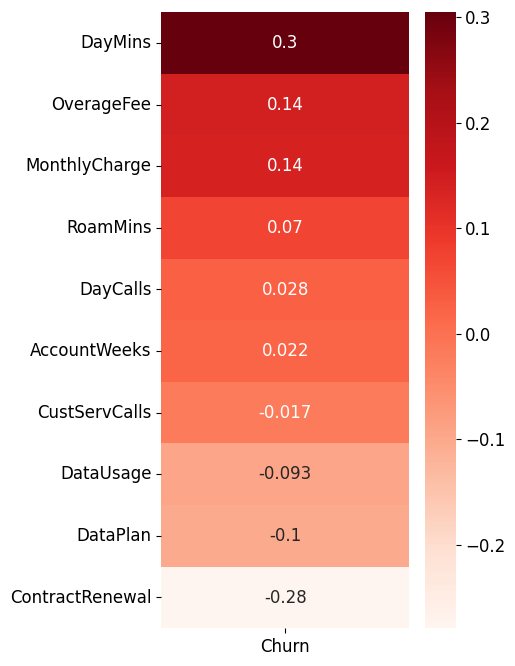

In [ ]:
correlacion(df, 'Churn')

##3. Feature engineering y codificación de atributos

In [ ]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1
5,0,118,0,0,0.0,0,223.4,98,57.0,11.03,6.3


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Identify numerical columns to scale (excluding 'Churn' if it's the target variable and already binary)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')

# Apply scaling to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after scaling numerical attributes:")
display(df.head())

DataFrame after scaling numerical attributes:


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,0.524793,1.0,1.0,0.609481,0.333333,0.794199,0.600000,0.900123,0.487537,0.485915
1,0,0.438017,1.0,1.0,0.835214,0.333333,0.436809,0.723810,0.813810,0.480938,0.746479
2,0,0.561983,1.0,0.0,0.000000,0.000000,0.719268,0.638095,0.443896,0.208211,0.640845
4,0,0.305785,0.0,0.0,0.000000,1.000000,0.454420,0.628571,0.308261,0.307918,0.492958
5,0,0.483471,0.0,0.0,0.000000,0.000000,0.650207,0.485714,0.505549,0.572581,0.225352


##4. Evaluación de modelos de Machime Learning

Se procederá a evaluar los modelos considerando un 20% de los registros contendidos en el DataFrame como set de prueba.

In [ ]:
X = df.drop('Churn', axis = 1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4.1. Modelo de árbol de decisión sin modificar parámetros por defecto

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

In [ ]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2089
           1       1.00      1.00      1.00       247

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336



### 4.2. Modelo árbol de decisión con hiperparámetros según grilla:

Modificando parámetros según grilla:
* max_depth: [5, 10, 15, 20. 25]
* min_sample_split: [0.01, 0.02, 0.03, 0.04]

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [0.01, 0.02, 0.03, 0.04]
}

# Create a DecisionTreeClassifier instance
dtc = DecisionTreeClassifier(random_state=42)

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1-score: {grid_search.best_score_:.4f}")

# Get the best estimator
best_tree_model = grid_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 5, 'min_samples_split': 0.01}
Best F1-score: 0.6000


In [ ]:
y_test_pred_best_tree = best_tree_model.predict(X_test)

In [ ]:

print(classification_report(y_test, y_test_pred_best_tree))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       516
           1       0.90      0.56      0.69        68

    accuracy                           0.94       584
   macro avg       0.92      0.78      0.83       584
weighted avg       0.94      0.94      0.94       584



## 5. Optimización de modelo del punto 4.2. mediante balanceo de clases usando SMOTE

Para balancear las clases del dataFrame analizado se procederá a separar los conjuntos de entrenamiento y test.

In [ ]:
X_train_SMOTE, X_test_SMOTE, y_train_SMOTE, y_test_SMOTE = train_test_split(X, y, test_size=0.2, random_state=42)

Se aplica SMOTE para crear compensar el desbalance de clases y se redefine nuevamente el conjunto X e y

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_SMOTE, y_train_SMOTE)

In [ ]:
y_resampled.value_counts()

,count
Churn,
1,2089
0,2089


In [ ]:
best_tree_model.fit(X_resampled, y_resampled)

DecisionTreeClassifier(max_depth=5, min_samples_split=0.01, random_state=42)

In [ ]:
y_resampled_pred_best_tree = best_tree_model.predict(X_resampled)

In [ ]:
print(classification_report(y_resampled, y_resampled_pred_best_tree))



              precision    recall  f1-score   support

           0       0.84      0.92      0.88      2089
           1       0.91      0.82      0.86      2089

    accuracy                           0.87      4178
   macro avg       0.87      0.87      0.87      4178
weighted avg       0.87      0.87      0.87      4178



**NOTA**: Se aprecia un efecto significativo con el uso de parámetros optimizados mediante el uso de**gridseachCV** y balance de clases utiliazndo **SMOTE** respecto al modelo que utiliza los parámetros **por defecto** manteniendo el desbalance de clases original.

**CONCLUSION:** Modelo optimizado utilizando GridsearchCV y SMOTE para balancear las clases presenta un rendimiento mucho mejor que el modelor por defecto para decir los clientes que probablemente vayan a irse de la compañía, utilizando como variables las contendidas en el DataFrame utilizado y modelo predictivo Decission Tree Classifier optimizado.

##6. Implementación de modelo Bagging con modelos heterogéneos

El conjunto de entrenamiento y test será el mismo utilizado anteriormente (X_resampled e y_resampled)

In [ ]:
X_resampled_train, X_resampled_test, y_resampled_train, y_resampled_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

A continuación se implementará un modelo Bagging considerando:


* Regresión logística
* Arbol de decisión (utlizando anteriormente)
* SVM C con kernel bf
* SVM C con Kernel Sigmoide



In [ ]:
Clf1 = LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
Clf2 = best_tree_model

In [ ]:
Clf3 = SVC(kernel='rbf', random_state=42, probability=True)

In [ ]:
Clf4 = SVC(kernel='sigmoid', random_state=42, probability=True)

In [ ]:
estimators = [Clf1, Clf2, Clf3, Clf4]

Considerar 200 muestras bootstrap (T)

In [ ]:
bagging_het(X_resampled_train, y_resampled_train, 200, estimators, X_resampled_test)

([SVC(probability=True, random_state=42),
  SVC(probability=True, random_state=42),
  DecisionTreeClassifier(max_depth=5, min_samples_split=0.01, random_state=42),
  SVC(kernel='sigmoid', probability=True, random_state=42),
  LogisticRegression(random_state=42, solver='liblinear'),
  SVC(kernel='sigmoid', probability=True, random_state=42),
  SVC(kernel='sigmoid', probability=True, random_state=42),
  DecisionTreeClassifier(max_depth=5, min_samples_split=0.01, random_state=42),
  LogisticRegression(random_state=42, solver='liblinear'),
  SVC(kernel='sigmoid', probability=True, random_state=42),
  DecisionTreeClassifier(max_depth=5, min_samples_split=0.01, random_state=42),
  SVC(probability=True, random_state=42),
  SVC(kernel='sigmoid', probability=True, random_state=42),
  SVC(kernel='sigmoid', probability=True, random_state=42),
  LogisticRegression(random_state=42, solver='liblinear'),
  DecisionTreeClassifier(max_depth=5, min_samples_split=0.01, random_state=42),
  LogisticRegress

In [ ]:
y_resampled_pred = bagging_het_predict(X_resampled_test, estimators)

In [ ]:
print(classification_report(y_resampled_test, y_resampled_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       455
           1       0.86      0.77      0.81       381

    accuracy                           0.84       836
   macro avg       0.84      0.83      0.83       836
weighted avg       0.84      0.84      0.84       836



##7. Implementación de modelo Random Forest

In [ ]:

modelo_rf = RandomForestClassifier(n_estimators=45, oob_score=True, random_state=42)


In [ ]:
modelo_rf.fit(X_resampled_train, y_resampled_train)


RandomForestClassifier(n_estimators=45, oob_score=True, random_state=42)

In [ ]:
print(classification_report(y_resampled_test, modelo_rf.predict(X_resampled_test)))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       455
           1       0.93      0.93      0.93       381

    accuracy                           0.93       836
   macro avg       0.93      0.93      0.93       836
weighted avg       0.93      0.93      0.93       836



In [ ]:
y_pred_proba_rf = modelo_rf.predict_proba(X_resampled_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_resampled_test, y_pred_proba_rf)
auc_score_rf = roc_auc_score(y_resampled_test, y_pred_proba_rf)

print(f"AUC Score for Random Forest Model: {auc_score_rf:.4f}")

AUC Score for Random Forest Model: 0.9820


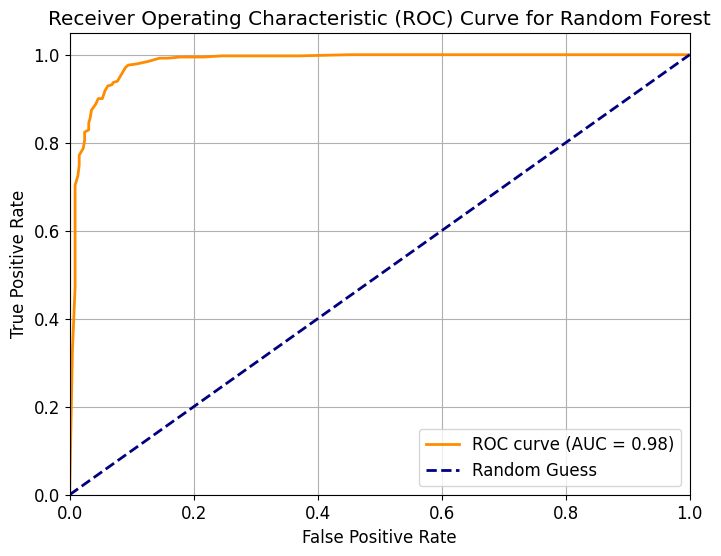


Summary: The Random Forest model achieved an AUC score of 0.9820.
This high AUC score (close to 1) indicates that the model has an excellent ability
to distinguish between churn and non-churn customers.
The ROC curve shows that the model maintains a high True Positive Rate (sensitivity)
while keeping the False Positive Rate (1-specificity) low across various threshold settings.
This suggests that the model is very effective at identifying potential churners correctly,
which is crucial for early churn detection and intervention strategies.


In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nSummary: The Random Forest model achieved an AUC score of {auc_score_rf:.4f}.\nThis high AUC score (close to 1) indicates that the model has an excellent ability\nto distinguish between churn and non-churn customers.\nThe ROC curve shows that the model maintains a high True Positive Rate (sensitivity)\nwhile keeping the False Positive Rate (1-specificity) low across various threshold settings.\nThis suggests that the model is very effective at identifying potential churners correctly,\nwhich is crucial for early churn detection and intervention strategies.")


##8. Determinando los 15 clientes más propensos a retirarse de la Compañía

In [ ]:
feature_importances = pd.Series(modelo_rf.feature_importances_, index=X_resampled.columns)
top_4_features = feature_importances.nlargest(4)
top_4_features.sort_values(ascending=False)

print("Top 4 Important Features:")
print(top_4_features)

Top 4 Important Features:
DayMins            0.186035
MonthlyCharge      0.181162
ContractRenewal    0.144351
OverageFee         0.098797
dtype: float64


In [ ]:
churn_probabilities = modelo_rf.predict_proba(X)[:, 1]
df_with_probabilities = df.copy()
df_with_probabilities['Churn_Probability'] = churn_probabilities

top_15_churn_customers = df_with_probabilities.sort_values(by='Churn_Probability', ascending=False).head(15)

print("Los 15 clientes con mayor propensión a renunciar:")
display(top_15_churn_customers[['AccountWeeks', 'MonthlyCharge', 'DayMins', 'ContractRenewal', 'Churn_Probability']].sort_values(by='DayMins', ascending=False))

Los 15 clientes con mayor propensión a renunciar:


,AccountWeeks,MonthlyCharge,DayMins,ContractRenewal,Churn_Probability
3272,0.545455,0.665845,0.897445,1.0,1.0
1736,0.471074,0.628853,0.867749,1.0,1.0
2451,0.747934,0.604192,0.843923,1.0,1.0
1000,0.545455,0.628853,0.836326,1.0,1.0
2354,0.417355,0.604192,0.822169,1.0,1.0
331,0.219008,0.641184,0.820097,1.0,1.0
1691,0.388430,0.616523,0.807666,1.0,1.0
3265,0.334711,0.604192,0.800414,1.0,1.0
3002,0.727273,0.604192,0.797652,1.0,1.0
1018,0.309917,0.604192,0.788329,1.0,1.0


Dado que los clientes cuya probabilidad de retirarse de la Compañía es mayor a 15 (Churn_Probability =1), se determinaron los 15 clientes más propensos, ordenando los registros del dataset obtenido, según el atributo DayMins (en orden descendente), el cual corresponde al atributo más importante (condición determinada al usar el método feature_importance).

#CONCLUSIONES GENERALES

Luego de realizar el análisis de los datos y habiendo implementado distintos modelos de Machine Learning para predecerir los clientes más propensos a retirarse de la Compañía, se puede concluir que el mejor modelo (de los evaluados) que permita a la Compañía anticiparse a la renuncia de un cliente, está basado en un modelo de Bosque Aleatorio.

El Bosque aleatorio está basado en varios modelos de árboles de decisión concatenados en forma secuencial. Esto permite que las predicciones vayan mejorando a medida que se van evaluando los modelos consecutivos.

Lo anterior es el motivo por el cual este modelo cuenta con mejores métricas que los modelos basasdos en Bagging ("Votación" entre resultados obtenidos por los distintos modelos de clasificación.)

